In [1]:
import numpy as np 
import xarray as xr
import pandas as pd
import zarr
import s3fs

from tqdm import tqdm
from datetime import datetime, timezone
from loguru import logger
import matplotlib.pyplot as plt

In [2]:
RCA_s3_bucket = "ooi-data/"
fs = s3fs.S3FileSystem(anon=True)

def load_data(stream_name):
    zarr_dir = RCA_s3_bucket + stream_name
    zarr_store = fs.get_mapper(zarr_dir)
    ds = xr.open_zarr(zarr_store, consolidated=True)
    return ds

In [3]:
START_YEAR = 2024
SITES_DICT = (
    pd.read_csv("https://raw.githubusercontent.com/OOI-CabledArray/rca-data-tools/refs/heads/main/rca_data_tools/qaqc/params/sitesDictionary.csv")
    .set_index('refDes')
    .T.to_dict('series')
)

VARIABLE_MAP = (
    pd.read_csv("https://raw.githubusercontent.com/OOI-CabledArray/rca-data-tools/refs/heads/main/rca_data_tools/qaqc/params/variableMap.csv")
    .set_index('parameter')
    .T.to_dict('series')
)

In [4]:
SITES_DICT["CE04OSPS-SF01B-2A-CTDPFA107"]["zarrFile"]

'CE04OSPS-SF01B-2A-CTDPFA107-streamed-ctdpf_sbe43_sample'

In [5]:
ds = load_data(SITES_DICT["CE04OSPS-SF01B-2A-CTDPFA107"]['zarrFile'])

In [6]:
ds

<xarray.Dataset> Size: 60GB
Dimensions:                                            (time: 322510410)
Coordinates:
  * time                                               (time) datetime64[ns] 3GB ...
Data variables: (12/39)
    conductivity                                       (time) float64 3GB ...
    corrected_dissolved_oxygen                         (time) float64 3GB ...
    corrected_dissolved_oxygen_qartod_executed         (time) <U1 1GB ...
    corrected_dissolved_oxygen_qartod_results          (time) uint8 323MB ...
    corrected_dissolved_oxygen_qc_executed             (time) uint8 323MB ...
    corrected_dissolved_oxygen_qc_results              (time) uint8 323MB ...
    ...                                                 ...
    sea_water_temperature                              (time) float64 3GB ...
    sea_water_temperature_qartod_executed              (time) <U2 3GB ...
    sea_water_temperature_qartod_results               (time) uint8 323MB ...
    sea_water_temperature_qc_executed                  (time) uint8 323MB ...
    sea_water_temperature_qc_results                   (time) uint8 323MB ...
    temperature                                        (time) float64 3GB ...
Attributes: (12/62)
    AssetManagementRecordLastModified:  2026-04-03T17:06:39.988000
    AssetUniqueID:                      ATOSU-66662-00007
    Conventions:                        CF-1.6
    Description:                        CTD Profiler: CTDPF Series A
    FirmwareVersion:                    Not specified.
    Manufacturer:                       Sea-Bird Electronics
    ...                                 ...
    stream:                             ctdpf_sbe43_sample
    subsite:                            CE04OSPS
    summary:                            Dataset Generated by Stream Engine fr...
    time_coverage_end:                  2026-05-06T10:08:56.221105664
    time_coverage_start:                2014-11-05T21:30:49.640057856
    title:                              Data produced by Stream Engine versio...

In [7]:
def load_regridding_inputs(refdes, param, append=True):
    
    now = datetime.now(timezone.utc)
    current_year = now.year
    if append:
        years = current_year
    else:
        years = list(range(START_YEAR, current_year + 1))
    
    site = refdes[:8]
    stream_name = SITES_DICT[refdes]['zarrFile']

    # get pressure param constants 
    pres_params = VARIABLE_MAP['pressure']['variableNames']
    profile_params = pres_params.strip('"').split(",")
    profile_params.append(param)

    logger.info("loading full time series zarr")
    ds = load_data(stream_name)

    available_params = [v for v in profile_params if v in ds]
    prof_ds = ds[available_params]
    
    logger.info("loading profile indices")
    profile_indices_list = []
    for year in years:
        profile_indices = pd.read_csv(
            f"https://raw.githubusercontent.com/OOI-CabledArray/profileIndices/refs/heads/main/{site}_profiles_{year}.csv"
        )
        profile_indices_list.append(profile_indices)

        all_indices = pd.concat(profile_indices_list, axis=0, ignore_index=True)


    return prof_ds, all_indices

In [ ]:
prof_ds, indices = load_regridding_inputs("CE04OSPS-SF01B-2A-CTDPFA107", "sea_water_temperature", False)

2026-05-06 10:18:07.071 | INFO     | __main__:load_regridding_inputs:18 - loading full time series zarr


In [ ]:
prof_ds

<xarray.Dataset> Size: 8GB
Dimensions:                (time: 322510410)
Coordinates:
  * time                   (time) datetime64[ns] 3GB 2014-11-05T21:30:49.6400...
Data variables:
    sea_water_pressure     (time) float64 3GB ...
    sea_water_temperature  (time) float64 3GB ...
Attributes: (12/62)
    AssetManagementRecordLastModified:  2026-04-03T17:06:39.988000
    AssetUniqueID:                      ATOSU-66662-00007
    Conventions:                        CF-1.6
    Description:                        CTD Profiler: CTDPF Series A
    FirmwareVersion:                    Not specified.
    Manufacturer:                       Sea-Bird Electronics
    ...                                 ...
    stream:                             ctdpf_sbe43_sample
    subsite:                            CE04OSPS
    summary:                            Dataset Generated by Stream Engine fr...
    time_coverage_end:                  2026-05-06T10:08:56.221105664
    time_coverage_start:                2014-11-05T21:30:49.640057856
    title:                              Data produced by Stream Engine versio...

In [16]:
print(prof_ds.time[0].values, "--->",prof_ds.time[-1].values)

2014-11-05T21:30:49.640057856 ---> 2026-05-06T10:08:56.221105664


In [17]:
indices

,profile,start,peak,end
0,11398,2024-01-02 18:52:00,2024-01-02 20:04:00,2024-01-02 20:08:00
1,11399,2024-01-02 21:07:00,2024-01-02 22:13:00,2024-01-02 22:17:00
2,11400,2024-01-02 23:16:00,2024-01-03 00:22:00,2024-01-03 00:26:00
3,11401,2024-01-03 01:25:00,2024-01-03 02:31:00,2024-01-03 02:35:00
4,11402,2024-01-03 03:34:00,2024-01-03 04:40:00,2024-01-03 09:03:00
...,...,...,...,...
7577,18975,2026-05-05 20:42:00,2026-05-05 21:50:00,2026-05-05 23:25:00
7578,18976,2026-05-06 00:27:00,2026-05-06 01:35:00,2026-05-06 02:10:00
7579,18977,2026-05-06 02:42:00,2026-05-06 03:50:00,2026-05-06 04:24:00
7580,18978,2026-05-06 04:52:00,2026-05-06 06:00:00,2026-05-06 06:35:00


In [18]:
# we kinda need two diferent products, a full resolution profiles with only n_profiles as dim (no time) 
# and then a regridded one

In [ ]:
%%time
pds = []
tp = 5
NEW_GRID = np.arange(0, 220, 0.25)

for idx, row in indices.head(tp).iterrows():
    
    ds_upcast = prof_ds.sel(time=slice(row['start'], row['peak']))

    _, idx = np.unique(ds_upcast["sea_water_pressure"].values, return_index=True)
    mask = np.zeros_like(ds_upcast["sea_water_pressure"].values, dtype=bool)
    mask[idx] = True

    # unique_pres = ds_upcast["sea_water_pressure"].values[mask]
    # unique_temp = ds_upcast["sea_water_temperature"].values[mask]
    unique_time = ds_upcast["time"].values[mask]
    ds_upcast = ds_upcast.sel(time=unique_time)
    
    # assign the profile number as a new coordinate
    ds_upcast = ds_upcast.assign_coords(profile_number=row['profile'])
    ds_upcast = ds_upcast.assign_coords(start_time=row['start'])
    ds_upcast = ds_upcast.assign_coords(peak_time=row['peak'])
    logger.info("swapping dims")
    ds_upcast = ds_upcast.swap_dims({"time": "sea_water_pressure"})
    logger.info("interpolating depth")
    
    ds_upcast = ds_upcast.drop_vars("time")
    ds_int = ds_upcast.interp(sea_water_pressure=NEW_GRID)

    pds.append(ds_int)

logger.info("concatenating")
ds_profiles = xr.concat(pds, dim='profile_number')

2026-05-06 10:16:45.160 | INFO     | __main__:<module>:22 - swapping dims
2026-05-06 10:16:45.161 | INFO     | __main__:<module>:24 - interpolating depth


CPU times: user 847 ms, sys: 786 ms, total: 1.63 s
Wall time: 9.42 s


ModuleNotFoundError: No module named 'scipy'

In [64]:
ds_profiles

<xarray.Dataset> Size: 43kB
Dimensions:                (profile_number: 5, sea_water_pressure: 880)
Coordinates:
  * profile_number         (profile_number) int64 40B 11398 11399 ... 11402
    start_time             (profile_number) <U19 380B '2024-01-02 18:52:00' ....
    peak_time              (profile_number) <U19 380B '2024-01-02 20:04:00' ....
  * sea_water_pressure     (sea_water_pressure) float64 7kB 0.0 0.25 ... 219.8
Data variables:
    sea_water_temperature  (profile_number, sea_water_pressure) float64 35kB dask.array<chunksize=(1, 880), meta=np.ndarray>
Attributes: (12/62)
    AssetManagementRecordLastModified:  2025-09-15T15:32:20.047000
    AssetUniqueID:                      ATOSU-66662-00007
    Conventions:                        CF-1.6
    Description:                        CTD Profiler: CTDPF Series A
    FirmwareVersion:                    Not specified.
    Manufacturer:                       Sea-Bird Electronics
    ...                                 ...
    stream:                             ctdpf_sbe43_sample
    subsite:                            CE04OSPS
    summary:                            Dataset Generated by Stream Engine fr...
    time_coverage_end:                  2025-10-03T10:07:37.323824640
    time_coverage_start:                2014-11-05T21:30:49.640057856
    title:                              Data produced by Stream Engine versio...

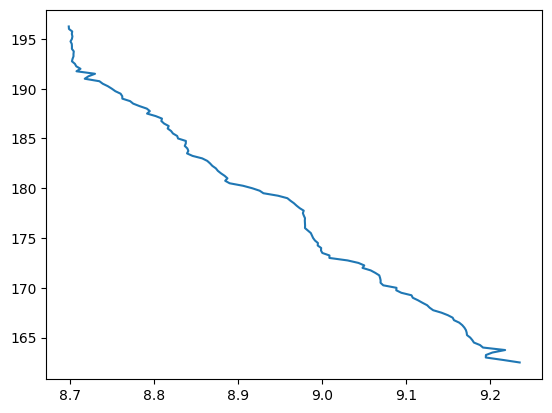

In [65]:
plt.plot(pds[0].sea_water_temperature, pds[0].sea_water_pressure)

/var/folders/2y/x544q5ss4sv2zynl3ft62lsm0000gn/T/ipykernel_47234/4179196829.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_profiles = ds_profiles.dims['profile_number']


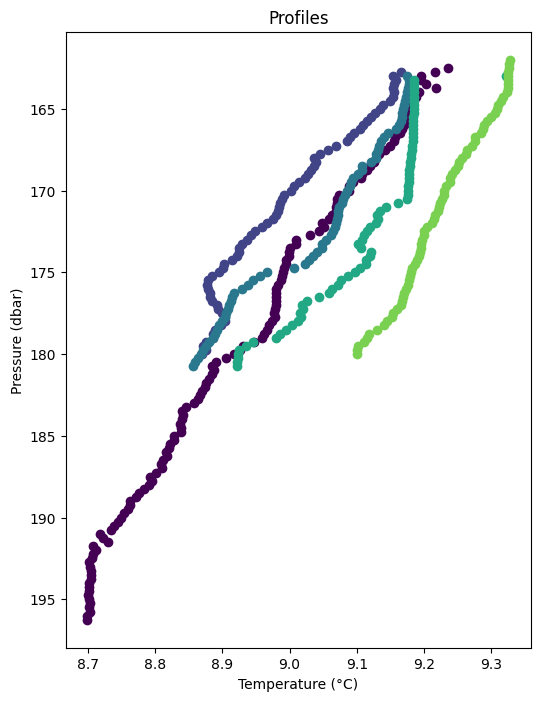

In [68]:
ds_profiles['sea_water_temperature'].compute()
ds_profiles['sea_water_pressure'].compute()

# Extract number of profiles
n_profiles = ds_profiles.dims['profile_number']

# Choose a colormap (e.g., 'viridis', 'plasma', 'gray')
cmap = plt.get_cmap('viridis')

# Scale colors from light to dark
colors = [cmap(i / n_profiles) for i in range(n_profiles)]

plt.figure(figsize=(6, 8))

for i, prof in enumerate(ds_profiles.profile_number.values):
    temp = ds_profiles['sea_water_temperature'].sel(profile_number=prof)
    pres = ds_profiles['sea_water_pressure'].values  # y-axis

    plt.scatter(temp, pres, color=colors[i], label=str(prof))

plt.gca().invert_yaxis()  # pressure increases downward
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (dbar)')
plt.title('Profiles')
plt.show()

In [ ]:
ds_profiles.sea_water_temperature.plot.line(y="sea_water_pressure", hue="profile_number")